Verifying Central Limit Theorem For Different Number Of Samples

In [19]:
import numpy as np 
import matplotlib.pyplot as plt

Part A Of Question - 1

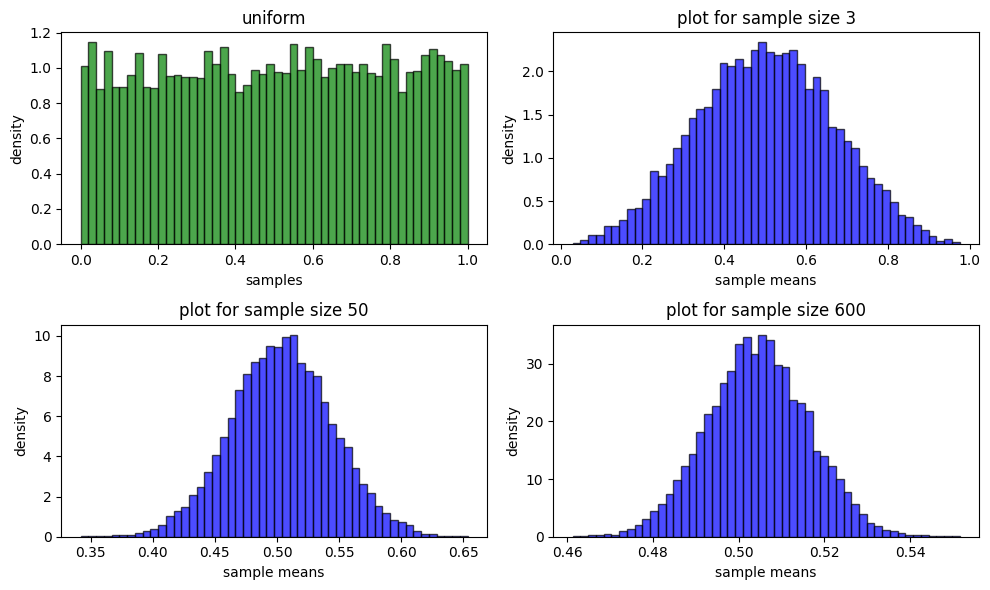

In [ ]:
# uniform distribution of [0,1] with 10000 sample points
unif_distribution = np.random.uniform(0,1,10000) # taking less sample points leads to non-uniformity in histogram

check_sample_pts = [3,50,600]
plt.figure(figsize=(10,6))
plt.subplot(2,2,1)
plt.hist(unif_distribution,bins=50,density=True,alpha = 0.7,color = "green",edgecolor = "black")
plt.title("uniform")
plt.xlabel("samples")
plt.ylabel("density")
plt.tight_layout()
for k,n in enumerate(check_sample_pts,2):
    l_samples_means = []
    for i in range(10000): # if we take sample less number of times then graph may be more non-normal
        # storing n - random elements from the uniform distribution.
        sample_elements = np.random.choice(unif_distribution,n,replace=True) 
        l_samples_means.append(np.mean(sample_elements))

    # so here we get the sample means for each quantity of sample points
    sample_means = np.array(l_samples_means)     
    
    plt.subplot(2,2,k)
    plt.hist(sample_means,bins = 50,density=True,alpha = 0.7,color="blue",edgecolor = "black")
    plt.title(f"plot for sample size {n}")
    plt.xlabel("sample means")
    plt.ylabel("density")
plt.tight_layout()
plt.show()

Part B of question 1

[]

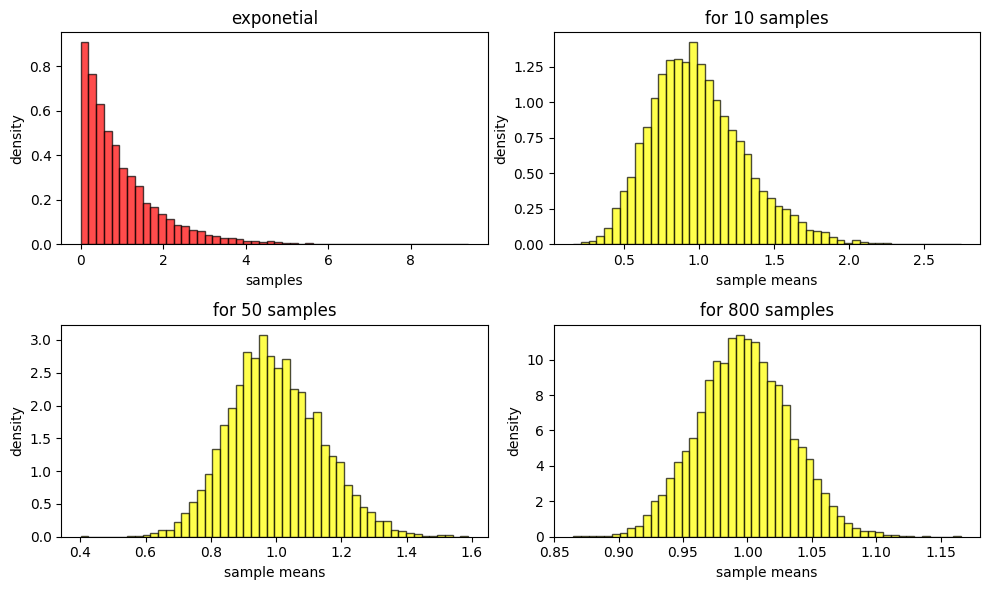

In [29]:
# exponential distribution for 1000 sample points
expo_dist = np.random.exponential(scale=1,size=10000)
plt.figure(figsize=(10,6))
plt.subplot(2,2,1)
# plotting the original distribution
plt.hist(expo_dist,bins=50,density=True,alpha = 0.7,color = "red",edgecolor="black")
plt.title("exponetial")
plt.xlabel("samples")
plt.ylabel("density")
plt.tight_layout()
# taking out different samples
choice_of_samples = [10,50,800]
for i,n in enumerate(choice_of_samples,2):
    means = []
    for k in range(10000):
        # choosing 1000 times, n samples from the distribution
        choose_sample = np.random.choice(expo_dist,n,replace=True)
        # storing their mean each time in the list 
        means.append(np.mean(choose_sample))
    # making an array from the list that has means in it approx 1000 sample means for each n.
    means_arr = np.array(means)
    plt.subplot(2,2,i)
    # plotting for each value of the sample taken
    plt.hist(means_arr,bins = 50,density=True,alpha = 0.7,color = "yellow",edgecolor = "black")
    plt.title(f"for {n} samples")
    plt.xlabel("sample means")
    plt.ylabel("density")
plt.tight_layout()
plt.plot()

Question 2 

In [31]:
import pandas as pd
from scipy.stats import multivariate_normal

In [ ]:
# reading the csv files.
df_train1 = pd.read_csv("dataset1_train.csv")
df_test1 = pd.read_csv("dataset1_test.csv")
# assigning col 1 and col 2 as features and 3rd column as classes.
features = df_train1.columns[0:2]
label = df_train1.columns[2]
# storing the feature (values) as well as class in the array
x_train = df_train1[features].values # features data from train
y_train = df_train1[label].values # classes data from train
x_test = df_test1[features].values # features from test
y_test = df_test1[label].values # classes from test
# check for classes
classes = np.sort(df_train1[label].unique())
print(classes)


[1 2]


part a). Now Using MLE estimating the parameters <mu1,mu2> and covariance matrices <sigma1,sigma2>

In [68]:

params = {} # to store mu and sigma
priors = {}
def mle_estimate(X):
    mu = np.mean(X,axis=0)
    sigma = np.cov(X,rowvar = False,bias = True) # row is here sample data not variable,bias true means divide by N not N-1.
    return mu,sigma

for c in classes:
    # storing the array of data of feature 1 and feature 2 of a class c(1 or 2) in a 2d array.
    Xc = x_train[c==y_train] # seperating the samples of different classes.
    mu, sigma = mle_estimate(Xc)
    params[c] = mu,sigma
    priors[c] = len(Xc)/len(x_train)
means = {}
means[1] , means[2] = params[1][0] ,params[2][0]
covs = {}
covs[1] ,covs[2]= params[1][1],params[2][1]
print(f"Paramter for class 1: \n u_1 = {means[1]}\n sigma_1 = {covs[1]}")
print(f"Paramter for class 2: \n u_2 = {means[2]}\n sigma_2 = {covs[2]}")


Paramter for class 1: 
 u_1 = [0.28643244 0.69279826]
 sigma_1 = [[0.00682389 0.00033128]
 [0.00033128 0.00948629]]
Paramter for class 2: 
 u_2 = [0.70281086 0.32278163]
 sigma_2 = [[0.00929122 0.00050833]
 [0.00050833 0.0113118 ]]


part b). Prior with the help of train data

In [61]:
# from the above cell the priors for two classes are calculate and stored in priors dict.
print(f"Prior for class 1 P(c1) = {priors[1]}")
print(f"Prior for class 2 P(c2) = {priors[2]}")

Prior for class 1 P(c1) = 0.5
Prior for class 2 P(c2) = 0.5


part c). computing posterior probabilty of each case in test dataset.

In [73]:
# Compute posterior probabilities on test set
posteriors = []

for x in x_test:
    numerators = {}
    for c in classes:
        # Likelihood P(x | C=c)
        likelihood = multivariate_normal.pdf(x, mean=means[c], cov=covs[c])
        numerators[c] = likelihood * priors[c] # un-normalised posterior since greater than 1.
    # Normalize (Bayes rule denominator)
    evidence = sum(numerators.values()) # total probability-> P(x)=j∑​P(x∣Cj​)P(Cj​)
    posterior = {c: numerators[c]/evidence for c in classes} # c-> key and other is value.
    posteriors.append(posterior) # forming list of dict. each cotaining posterior probability corresponding to each test case.
for i, posterior in enumerate(posteriors):
    print(f"Test point {i+1}:")
    for c, p in posterior.items():
        print(f"  P(C={c} | x) = {p:.4f}")
    print("\n")

   

Test point 1:
  P(C=1 | x) = 1.0000
  P(C=2 | x) = 0.0000


Test point 2:
  P(C=1 | x) = 1.0000
  P(C=2 | x) = 0.0000


Test point 3:
  P(C=1 | x) = 1.0000
  P(C=2 | x) = 0.0000


Test point 4:
  P(C=1 | x) = 0.9991
  P(C=2 | x) = 0.0009


Test point 5:
  P(C=1 | x) = 1.0000
  P(C=2 | x) = 0.0000


Test point 6:
  P(C=1 | x) = 1.0000
  P(C=2 | x) = 0.0000


Test point 7:
  P(C=1 | x) = 1.0000
  P(C=2 | x) = 0.0000


Test point 8:
  P(C=1 | x) = 1.0000
  P(C=2 | x) = 0.0000


Test point 9:
  P(C=1 | x) = 1.0000
  P(C=2 | x) = 0.0000


Test point 10:
  P(C=1 | x) = 1.0000
  P(C=2 | x) = 0.0000


Test point 11:
  P(C=1 | x) = 0.9999
  P(C=2 | x) = 0.0001


Test point 12:
  P(C=1 | x) = 0.9816
  P(C=2 | x) = 0.0184


Test point 13:
  P(C=1 | x) = 1.0000
  P(C=2 | x) = 0.0000


Test point 14:
  P(C=1 | x) = 1.0000
  P(C=2 | x) = 0.0000


Test point 15:
  P(C=1 | x) = 1.0000
  P(C=2 | x) = 0.0000


Test point 16:
  P(C=1 | x) = 1.0000
  P(C=2 | x) = 0.0000


Test point 17:
  P(C=1 | x) = 1.0

part d and e). Now Classifying the test data according to train dataset.
plotting the test cases according to classified classes with different colors.

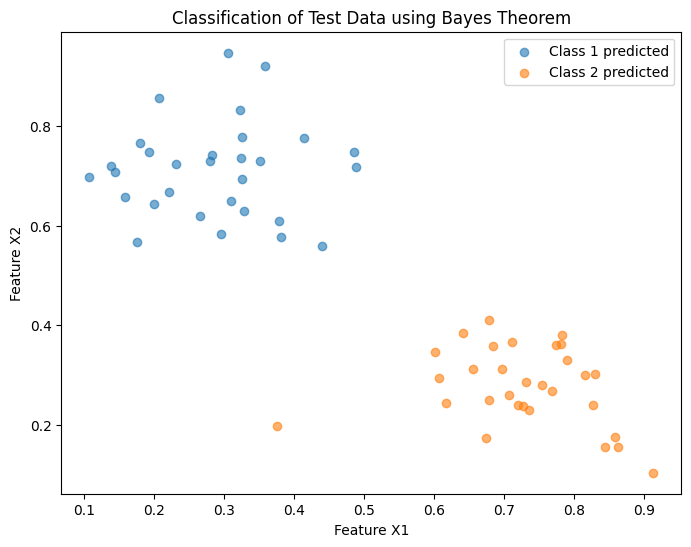

In [ ]:
# list y_pred means prediction of testcase holds the max posterior probability(argmax()) for each test case.
y_pred = [max(p, key=p.get) for p in posteriors] # it predict the particular test case wheather it is from class 1 or 2.
plt.figure(figsize=(8,6))

# plot test points with predicted class color
for c in classes:
    plt.scatter(x_test[np.array(y_pred)==c, 0], 
                x_test[np.array(y_pred)==c, 1], 
                label=f"Class {c} predicted", alpha=0.6)

plt.title("Classification of Test Data using Bayes Theorem")
plt.xlabel("Feature X1")
plt.ylabel("Feature X2")
plt.legend()
plt.show()


Now repeating the same for dataset 2.

[1 2]
Paramter for class 1: 
 u_1 = [0.50279938 0.50981493]
 sigma_1 = [[ 0.01888129 -0.00203952]
 [-0.00203952  0.01479241]]
Paramter for class 2: 
 u_2 = [0.57722241 0.57290926]
 sigma_2 = [[0.01805917 0.00163931]
 [0.00163931 0.01864453]]
Prior for class 1 P(c1) = 0.5
Prior for class 2 P(c2) = 0.5
Test point 1:
  P(C=1 | x) = 0.0644
  P(C=2 | x) = 0.9356


Test point 2:
  P(C=1 | x) = 0.5091
  P(C=2 | x) = 0.4909


Test point 3:
  P(C=1 | x) = 0.2686
  P(C=2 | x) = 0.7314


Test point 4:
  P(C=1 | x) = 0.6726
  P(C=2 | x) = 0.3274


Test point 5:
  P(C=1 | x) = 0.6370
  P(C=2 | x) = 0.3630


Test point 6:
  P(C=1 | x) = 0.6583
  P(C=2 | x) = 0.3417


Test point 7:
  P(C=1 | x) = 0.5501
  P(C=2 | x) = 0.4499


Test point 8:
  P(C=1 | x) = 0.3945
  P(C=2 | x) = 0.6055


Test point 9:
  P(C=1 | x) = 0.6006
  P(C=2 | x) = 0.3994


Test point 10:
  P(C=1 | x) = 0.7913
  P(C=2 | x) = 0.2087


Test point 11:
  P(C=1 | x) = 0.5480
  P(C=2 | x) = 0.4520


Test point 12:
  P(C=1 | x) = 0.8240

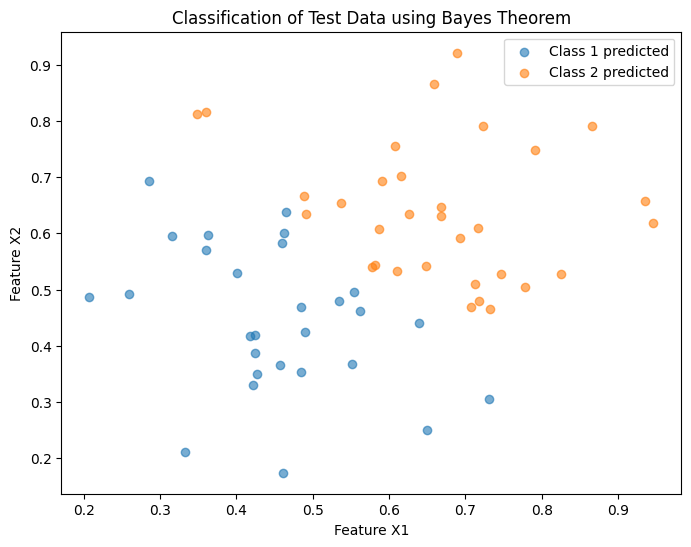

In [75]:
# reading the csv files.
df_train2 = pd.read_csv("dataset2_train.csv")
df_test2 = pd.read_csv("dataset2_test.csv")
# assigning col 1 and col 2 as features and 3rd column as classes.
features = df_train2.columns[0:2]
label = df_train2.columns[2]
# storing the feature (values) as well as class in the array
x_train = df_train2[features].values # features data from train
y_train = df_train2[label].values # classes data from train
x_test = df_test2[features].values # features from test
y_test = df_test2[label].values # classes from test
# check for classes
classes = np.sort(df_train2[label].unique())
print(classes)


params = {} # to store mu and sigma
priors = {}
def mle_estimate(X):
    mu = np.mean(X,axis=0)
    sigma = np.cov(X,rowvar = False,bias = True) # row is here sample data not variable,bias true means divide by N not N-1.
    return mu,sigma

for c in classes:
    # storing the array of data of feature 1 and feature 2 of a class c(1 or 2) in a 2d array.
    Xc = x_train[c==y_train] # seperating the samples of different classes.
    mu, sigma = mle_estimate(Xc)
    params[c] = mu,sigma
    priors[c] = len(Xc)/len(x_train)
means = {}
means[1] , means[2] = params[1][0] ,params[2][0]
covs = {}
covs[1] ,covs[2]= params[1][1],params[2][1]
print(f"Paramter for class 1: \n u_1 = {means[1]}\n sigma_1 = {covs[1]}")
print(f"Paramter for class 2: \n u_2 = {means[2]}\n sigma_2 = {covs[2]}")


# from the above cell the priors for two classes are calculate and stored in priors dict.
print(f"Prior for class 1 P(c1) = {priors[1]}")
print(f"Prior for class 2 P(c2) = {priors[2]}")


# Compute posterior probabilities on test set
posteriors = []

for x in x_test:
    numerators = {}
    for c in classes:
        # Likelihood P(x | C=c)
        likelihood = multivariate_normal.pdf(x, mean=means[c], cov=covs[c])
        numerators[c] = likelihood * priors[c] # un-normalised posterior since greater than 1.
    # Normalize (Bayes rule denominator)
    evidence = sum(numerators.values()) # total probability-> P(x)=j∑​P(x∣Cj​)P(Cj​)
    posterior = {c: numerators[c]/evidence for c in classes} # c-> key and other is value.
    posteriors.append(posterior) # forming list of dict. each cotaining posterior probability corresponding to each test case.
for i, posterior in enumerate(posteriors):
    print(f"Test point {i+1}:")
    for c, p in posterior.items():
        print(f"  P(C={c} | x) = {p:.4f}")
    print("\n")


# list y_pred means prediction of testcase holds the max posterior probability(argmax()) for each test case.
y_pred = [max(p, key=p.get) for p in posteriors] # it predict the particular test case wheather it is from class 1 or 2.
plt.figure(figsize=(8,6))

# plot test points with predicted class color
for c in classes:
    plt.scatter(x_test[np.array(y_pred)==c, 0], 
                x_test[np.array(y_pred)==c, 1], 
                label=f"Class {c} predicted", alpha=0.6)

plt.title("Classification of Test Data using Bayes Theorem")
plt.xlabel("Feature X1")
plt.ylabel("Feature X2")
plt.legend()
plt.show()

